In [2]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

In [3]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

from ucimlrepo import fetch_ucirepo

cdc = fetch_ucirepo(id=891)

X = cdc.data.features
y = cdc.data.targets

print("Shape X:", X.shape)
print("Shape y:", y.shape)


Shape X: (253680, 21)
Shape y: (253680, 1)


In [4]:
# Sostituisco X e y con un unico DataFrame
df = pd.concat([X,y], axis=1)

df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [5]:
df.shape

(253680, 22)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              253680 non-n

Osservazioni:

- Il dataset contiene 253.680 osservazioni.
- Sono presenti 21 feature e una variabile target.
- Non sono presenti valori mancanti.
- La maggior parte delle feature è di tipo nominale binario.
- Age, Education, Income e GenHlth sono attributi ordinali.
- BMI, MentHlth e PhysHlth sono attributi numerici.
- La variabile target è Diabetes_binary.

| Attributo            | Tipo             | Motivazione                         |
| -------------------- | ---------------- | ----------------------------------- |
| HighBP               | Nominale binario | 0 = No, 1 = Yes                     |
| HighChol             | Nominale binario | 0 = No, 1 = Yes                     |
| CholCheck            | Nominale binario | 0 = No, 1 = Yes                     |
| BMI                  | Numerico intero  | Misura quantitativa                 |
| Smoker               | Nominale binario | 0 = No, 1 = Yes                     |
| Stroke               | Nominale binario | 0 = No, 1 = Yes                     |
| HeartDiseaseorAttack | Nominale binario | 0 = No, 1 = Yes                     |
| PhysActivity         | Nominale binario | 0 = No, 1 = Yes                     |
| Fruits               | Nominale binario | 0 = No, 1 = Yes                     |
| Veggies              | Nominale binario | 0 = No, 1 = Yes                     |
| HvyAlcoholConsump    | Nominale binario | 0 = No, 1 = Yes                     |
| AnyHealthcare        | Nominale binario | 0 = No, 1 = Yes                     |
| NoDocbcCost          | Nominale binario | 0 = No, 1 = Yes                     |
| GenHlth              | Ordinale         | Livello di salute generale da 1 a 5 |
| MentHlth             | Numerico intero  | Giorni di cattiva salute mentale    |
| PhysHlth             | Numerico intero  | Giorni di cattiva salute fisica     |
| DiffWalk             | Nominale binario | 0 = No, 1 = Yes                     |
| Sex                  | Nominale binario | 0 = Female, 1 = Male                |
| Age                  | Ordinale         | Fasce d'età ordinate                |
| Education            | Ordinale         | Livelli di istruzione ordinati      |
| Income               | Ordinale         | Fasce di reddito ordinate           |
| Diabetes_binary      | Target binario   | Classe da predire                   |


In [8]:
# Questo ci permette di capire quanti soggetti sono diabetici e quanti non lo sono all'interno del dataset.

df["Diabetes_binary"].value_counts()

Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64

In [9]:
# Analisi della distribuzione percentuale della variabile target.

df["Diabetes_binary"].value_counts(normalize=True) * 100

Diabetes_binary
0    86.066698
1    13.933302
Name: proportion, dtype: float64

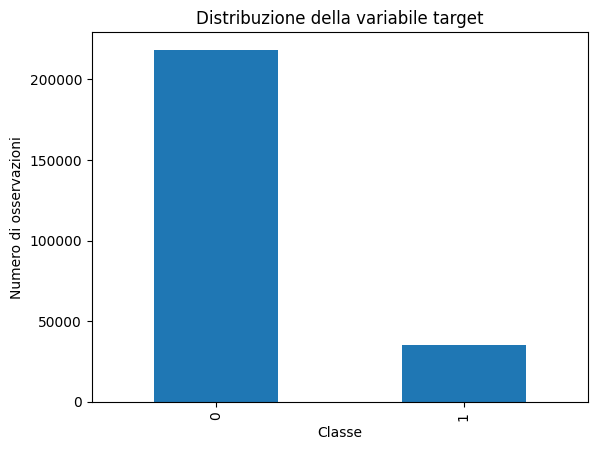

In [11]:
import matplotlib.pyplot as plt

# Rappresentazione grafica della distribuzione della variabile target.
# Il grafico permette di visualizzare immediatamente l'eventuale sbilanciamento tra le classi.

df["Diabetes_binary"].value_counts().plot(kind="bar")

plt.title("Distribuzione della variabile target")
plt.xlabel("Classe")
plt.ylabel("Numero di osservazioni")

plt.show()

### Osservazioni

- La variabile target è `Diabetes_binary`.
- La classe 0 rappresenta i soggetti non diabetici : 86.07% 
- La classe 1 rappresenta i soggetti diabetici : 13.93%
- Il dataset risulta sbilanciato
- Per questo motivo nelle fasi successive non verrà utilizzata solamente l'accuracy, ma anche precision, recall e F1-score.
- Durante la suddivisione training/test verrà utilizzata la stratificazione per mantenere inalterata la distribuzione delle classi.

In [12]:
# Verifica della presenza di valori mancanti.

df.isnull().sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64

### Analisi dei valori mancanti

È stata verificata la presenza di valori mancanti mediante il metodo `isnull().sum()`.
L'analisi ha evidenziato che nessuna delle 22 colonne contiene valori mancanti.
Di conseguenza non è stato necessario eliminare delle osservazioni.


In [13]:
# Verifica della presenza di osservazioni duplicate.

df.duplicated().sum()

np.int64(24206)

### Analisi delle osservazioni duplicate

È stata verificata la presenza di osservazioni duplicate mediante il metodo `duplicated().sum()`.
L'analisi ha individuato 24.206 record duplicati su un totale di 253.680 osservazioni.
La presenza di duplicati non implica necessariamente un errore nei dati, poiché il dataset contiene numerose variabili categoriali e diversi soggetti possono condividere le stesse caratteristiche.

In [14]:
# Calcolo delle principali statistiche descrittive per individuare eventuali valori anomali.

df.describe()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,...,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875,0.139333
std,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,...,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148,0.346294
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,0.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,0.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000


### Analisi statistica preliminare

Sono state calcolate le principali statistiche descrittive delle variabili mediante il metodo `describe()`.
L'analisi non ha evidenziato valori palesemente errati o incompatibili con il significato delle variabili. In particolare:
- BMI assume valori compresi tra 12 e 98;
- MentHlth e PhysHlth assumono valori compresi tra 0 e 30 giorni;
- Age è codificata come variabile ordinale compresa tra 1 e 13;
- Education assume valori compresi tra 1 e 6;
- Income assume valori compresi tra 1 e 8.
Non sono stati individuati valori negativi
Si conclude pertanto che il dataset presenta un buon livello di qualità e non richiede interventi significativi di pulizia.